# 

In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import regionate
from pathlib import Path
import warnings
import seaborn as sns
import gsw
import matplotlib.patheffects as pe

sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings(
    "ignore",
    message=r".*Approximating coordinate system.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="All-NaN slice encountered",
    category=RuntimeWarning,
    module="dask.array.reductions",
)


In [2]:
from dask.distributed import LocalCluster
cluster = LocalCluster()        
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 6
Total threads: 36,Total memory: 187.53 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37818,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33381,Total threads: 6
Dashboard: /proxy/39946/status,Memory: 31.26 GiB
Nanny: tcp://127.0.0.1:34022,


In [3]:
import cmocean
import cmocean.cm as cmo
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'}, #originally mol/m^3
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmol kg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}


In [4]:
def update_transient_tracers(ds): 
    ds["sf6"] = 1 * ds["sf6"] * variable_kwargs["sf6"]["conversion"]
    ds["cfc11"] = 1 * ds["cfc11"] * variable_kwargs["cfc11"]["conversion"]
    ds["cfc12"] = 1 * ds["cfc12"] * variable_kwargs["cfc12"]["conversion"]
    
    ds["sf6"].attrs["units"] = "fmol kg-1"
    ds["cfc11"].attrs["units"] = "pmol kg-1"
    ds["cfc12"].attrs["units"] = "pmol kg-1"
    return ds
    
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds_bottom = xr.open_mfdataset(ds_path).drop_vars(["lon", "lat"])

ds_bottom = ds_bottom.assign_coords({"lon":1 * ds_bottom["geolon"].compute(), "lat":1 * ds_bottom["geolat"].compute()})
ds_bottom.coords["lon"].values = ds_bottom.coords["lon"].values % 360
ds_bottom = ds_bottom.sel(year = slice(None, 2099))

ds_bottom = update_transient_tracers(ds_bottom)


detection_level = {"cfc11": 0.01, "cfc12": 0.01, "sf6": 0.1}

wet = ds_bottom["deptho"] > 0

for tracer, thresh in detection_level.items():
    ok = (ds_bottom[tracer] > thresh) & wet

    arrival = (
        ds_bottom["year"]
        .where(ok)
        .min("year", skipna=True)
        .where(ok.any("year"))
        .where(wet)
    )

    ds_bottom[f"{tracer}_arrival"] = arrival


expt_colors = {"forced":"r", "control":"b"}
expt_names = {"forced":"Historical/SSP5-8.5", "control":"piControl"}


In [5]:
from regionate import MaskRegions, GriddedRegion

coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
}
boundary = {'X':'periodic', 'Y':'extend'}
metrics = {('X','Y'):'areacello'}
grid = xgcm.Grid(ds_bottom, coords=coords, metrics=metrics, boundary=boundary, autoparse_metadata=False)

regions = MaskRegions((ds_bottom.deptho.fillna(0.0) <= 1000) * (ds_bottom.geolat <= -40), grid).region_dict
antarctic = regions[0] #there are more in this list if there are multiple contours 
region = GriddedRegion("antarctic", antarctic.lons_c, antarctic.lats_c, grid, 
                       ij=(antarctic.i_c, antarctic.j_c))

ASC_contour = region.mask

In [6]:
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.path import Path
import matplotlib.colors as colors
import matplotlib as mpl


plot_shelf = lambda ax, c = "w": ax.contour(ASC_contour.geolon, ASC_contour.geolat, 
                                   ASC_contour.data, transform = proj, colors = c, linewidths = 1)
add_land = lambda ax: ax.add_feature(cfeature.LAND, facecolor="lightgrey", edgecolor="none")

def plot_bottom_cfc_arrival(fig, ax, proj, add_colorbar=False, cbar_kwargs=None, expt = "control"): 
    levels = np.arange(1950, 1990, 2.5)
    ticks = np.arange(1950, 1990, 5.0)

    da = ds_bottom["cfc11_arrival"].sel(expt=expt).sel(yh=slice(None, 180))

    cmap = cmo.tempo.copy()
    norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend="both")

    ax.set_facecolor("white")
    ax.patch.set_facecolor("white")

    cb = ax.pcolormesh(
        da.geolon,
        da.geolat,
        da.data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="nearest",
        zorder=1,
    )

    if add_colorbar:
        kw = {
            "ax": ax,
            "orientation": "horizontal",
            "ticks": ticks,
            "pad": 0.07,
            "label": (
                "CFC-11 arrival year (> 0.01 pmol kg$^{-1}$)\n"
                f"({expt_names[expt]})"
            ),
        }
        fig.colorbar(cb, **(kw | (cbar_kwargs or {})))

    return cb
    
def plot_bottom_cfc(fig, ax, proj, add_colorbar = False, cbar_kwargs=None, expt = "control"): 
    da = ds_bottom["cfc11"].sel(expt=expt, year=1990)
    da = da.where(da > 0.01).sel(yh = slice(None, 180))
    
    levels = np.arange(0, 5.01, 0.25)
    ticks = np.arange(0, 5.01, 0.5)
    cb = ax.contourf(da.geolon, da.geolat, da.data, levels = levels, 
                     transform = proj,
                     cmap = cmo.matter, extend = "max")
    if add_colorbar:
        kw = {
            "ax": ax,
            "orientation": "horizontal",
            "ticks": ticks,
            "pad": 0.07,
            "label": (
                f"CFC-11 concentrations in {da.year.item()} [pmol kg$^{{-1}}$]\n"
                f"({expt_names[expt]})"
            ),
        }
        fig.colorbar(cb, **(kw | (cbar_kwargs or {})))
    return cb
    

def setup_antarctic_axis(fig, spec, max_lat=-60):
    proj = ccrs.PlateCarree()

    theta = np.linspace(0, 2 * np.pi, 200)
    circle = Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)

    ax = fig.add_subplot(spec, projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, max_lat], proj)
    ax.set_boundary(circle, transform=ax.transAxes)

    gl = ax.gridlines(draw_labels=False, color="darkgray", alpha=0.5)
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 30))

    for lon in np.arange(-150, 181, 30):
        lon_wrapped = ((lon + 180) % 360) - 180
        rot = -lon
        rot = rot - 180 if rot > 90 else rot + 180 if rot < -90 else rot
        label = (
            "0°" if lon_wrapped == 0 else
            "180°" if abs(lon_wrapped) == 180 else
            f"{abs(lon_wrapped):g}°{'E' if lon_wrapped > 0 else 'W'}"
        )

        ax.text(lon, max_lat + 1.5, label, rotation=rot, color="gray", fontsize=10,
                ha="center", va="center", transform=proj)

    for lat in [70, 75, 80]:
        ax.text(105, -lat + 1.5, f"{lat}°S", rotation=75, color="gray", fontsize=10,
                ha="center", va="center", transform=proj)

    add_land(ax)

    return ax, proj

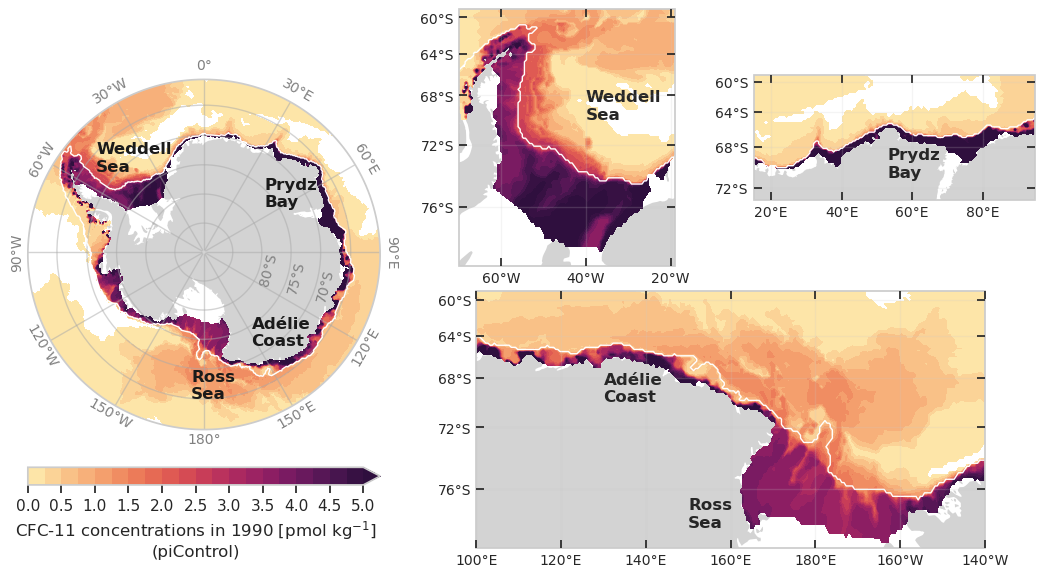

In [7]:
regions = {
    "weddell": {
        "extent": [-70, -19, -79, -59],
        "central_longitude": 0,
        "xticks": np.arange(-60, -19, 20),
        "yticks": np.arange(-76, -59, 4),
        "labels": [(-40, -70, "Weddell\nSea")],
    },
    "prydz": {
        "extent": [15, 95, -73, -59],
        "central_longitude": 0,
        "xticks": np.arange(20, 100, 20),
        "yticks": np.arange(-72, -59, 4),
        "labels": [(53, -71, "Prydz\nBay")],
    },
    "adelie_ross": {
        "extent": [100, 200, -79, -59],
        "central_longitude": 180,
        "xticks": [100, 120, 140, 160, 180, -160, -140],
        "yticks": np.arange(-76, -59, 4),
        "labels": [(130, -70, "Adélie\nCoast"), (150, -78, "Ross\nSea")],
    },
}

global_region_labels = {"weddell": {"label": "Weddell\nSea", "x": -53, "y": -67}, 
                       "prydz": {"label": "Prydz\nBay", "x": 53, "y": -77}, 
                       "adelie": {"label": "Adélie\nCoast", "x": 153, "y": -72}, 
                       "ross": {"label": "Ross\nSea", "x": -175, "y": -65}, }




fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1], wspace=0.15, hspace=0.1)

ax_global, proj = setup_antarctic_axis(fig, gs[:, 0])
cb = plot_bottom_cfc(fig, ax_global, proj, add_colorbar=True)
plot_shelf(ax_global)

for region_key in global_region_labels.keys(): 
    region = global_region_labels[region_key]
    ax_global.text(region["x"], region["y"], region["label"], fontweight="bold", transform=proj, c = "k")

specs = {
    "weddell": gs[0, 1],
    "prydz": gs[0, 2],
    "adelie_ross": gs[1, 1:],
}

for name, region in regions.items():
    proj = ccrs.PlateCarree()

    ax = fig.add_subplot(
        specs[name],
        projection=ccrs.Mercator(
            central_longitude=region["central_longitude"],
            min_latitude=-80,
            max_latitude=-50,
            latitude_true_scale=-70,
        ),
    )

    ax.set_extent(region["extent"], proj)
    add_land(ax)

    cb = plot_bottom_cfc(fig, ax, proj)
    plot_shelf(ax)

    gl = ax.gridlines(draw_labels=False, crs=proj, alpha=0.1)
    gl.xlocator = mticker.FixedLocator(region["xticks"])
    gl.ylocator = mticker.FixedLocator(region["yticks"])
    
    ax.set_xticks(region["xticks"], crs=proj)
    ax.set_yticks(region["yticks"], crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    
    for lon, lat, label in region["labels"]:
        ax.text(lon, lat, label, fontweight="bold", transform=proj)
        
    ax.tick_params(direction="in", labelsize=10,
                   top=True, right=True, left = True, bottom = True, 
                   labeltop=False, labelright=False)
    
    ax.xaxis.set_zorder(5)
    ax.yaxis.set_zorder(5)
    ax.grid(alpha = 0.1)

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/reductions.py:292: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/reductions.py:292: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/reductions.py:292: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/reductions.py:292: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/reductions.py:292: RuntimeWar

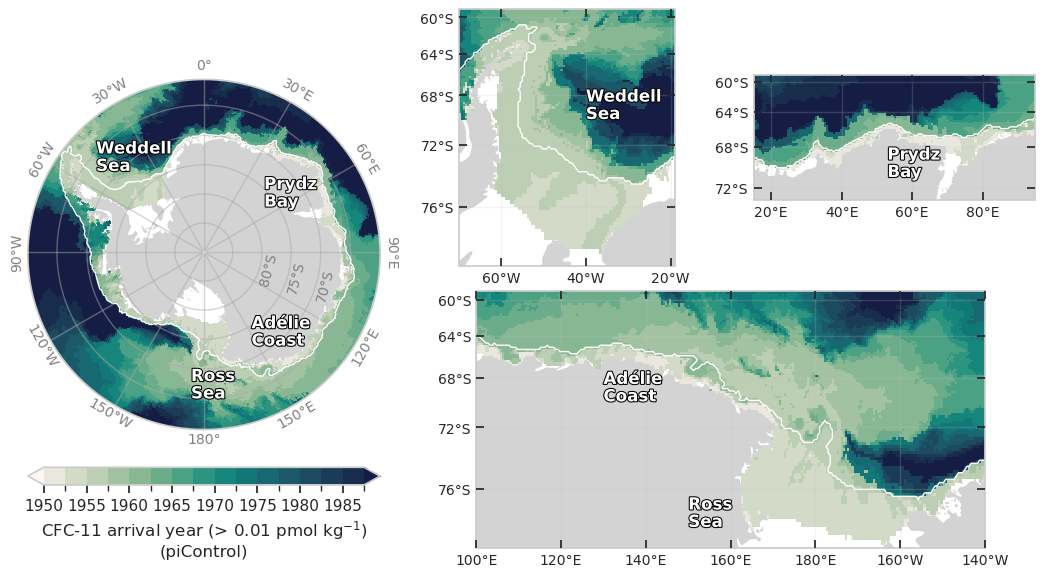

In [8]:
fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1], wspace=0.15, hspace=0.1)

ax_global, proj = setup_antarctic_axis(fig, gs[:, 0])
cb = plot_bottom_cfc_arrival(fig, ax_global, proj, add_colorbar=True)
plot_shelf(ax_global)

for region_key in global_region_labels.keys(): 
    region = global_region_labels[region_key]
    ax_global.text(region["x"], region["y"], region["label"], fontweight="bold", transform=proj,
               color="white", path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])
    
specs = {
    "weddell": gs[0, 1],
    "prydz": gs[0, 2],
    "adelie_ross": gs[1, 1:],
}

for name, region in regions.items():
    proj = ccrs.PlateCarree()

    ax = fig.add_subplot(
        specs[name],
        projection=ccrs.Mercator(
            central_longitude=region["central_longitude"],
            min_latitude=-80,
            max_latitude=-50,
            latitude_true_scale=-70,
        ),
    )

    ax.set_extent(region["extent"], proj)
    add_land(ax)

    cb = plot_bottom_cfc_arrival(fig, ax, proj)
    plot_shelf(ax)

    gl = ax.gridlines(draw_labels=False, crs=proj, alpha=0.1)
    gl.xlocator = mticker.FixedLocator(region["xticks"])
    gl.ylocator = mticker.FixedLocator(region["yticks"])
    
    ax.set_xticks(region["xticks"], crs=proj)
    ax.set_yticks(region["yticks"], crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    for lon, lat, label in region["labels"]:
        ax.text(lon, lat, label, fontweight="bold", transform=proj,
               color="white", path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])

    ax.tick_params(direction="in", labelsize=10,
                   top=True, right=True, left = True, bottom = True, 
                   labeltop=False, labelright=False)
    
    ax.xaxis.set_zorder(5)
    ax.yaxis.set_zorder(5)
    ax.grid(alpha = 0.1)

In [9]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.sel(yh = slice(None, 180), year = slice(None, 2099))
    
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")
ds["depth"] = approximate_z_bottom_up(ds, dim="z_l")
ds = ds.drop_vars(["volcello", "thkcello", "sigma2"])
ds = update_transient_tracers(ds)

In [10]:
from scipy.interpolate import interp1d

def interp_1d(q, z, z0):
    ok = np.isfinite(q) & np.isfinite(z)
    if ok.sum() < 2 or not np.isfinite(z0):
        return np.nan

    z, q = z[ok], q[ok]
    if np.any(np.diff(z) <= 0):
        raise ValueError("z must increase")

    return np.interp(z0, z, q, left=np.nan, right=q[-1])
    
def interpolate_cm4x_to_point(ds, obs_points, interpolate_to_depth_point = False): 
    
    regridder = xe.Regridder(ds["deptho"], obs_points[["lon", "lat"]], "bilinear", locstream_out=True, periodic = True)
    ds_regrid = regridder(ds)
    ds_regrid = ds_regrid#.compute()
    
    return ds_regrid


def interpolate_depth(ds, obs_points): 
    names = ["cfc11", "cfc12", "sf6", "sigma2_offline", "so", "thetao", "z"]

    new_ds_dict = {}

    for name in names: 
        if name == "depth": 
            vname = "interpolated_depth"
        else: 
            vname = name
            
        new_ds_dict[vname] = xr.apply_ufunc(
                interp_1d,
                ds[name],
                ds["z"],
                obs_points["depth"],
                input_core_dims=[["z_l"], ["z_l"], []],
                output_core_dims=[[]],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[ds[name].dtype],)
        
    ds_regrid = xr.Dataset(new_ds_dict)
    return ds_regrid


In [11]:

# names = ["adelie", "ross_west", "ross_east", "interior"]
# n = len(names)
# locs = xr.Dataset(
#     {
#         "print_name": ("obs_loc", ["Adélie", "Western Ross", "Eastern Ross", "Interior"]),
#         "lat":        ("obs_loc", [-66.5, -70.7, -74.5, -67.0]),
#         "lon":        ("obs_loc", [142.0, 168.5, -178.0 % 360, -170.0 % 360]),
#         "depth":      ("obs_loc", np.full(n, np.nan)),
#         "R_km":       ("obs_loc", [100.0, 100.0, 100.0, 100.0]),
#     },
#     coords={"obs_loc": names},
#     attrs={"description": "Sparse observation target locations."},
# )

names = ["adelie", "ross", "interior"]
n = len(names)

locs = xr.Dataset(
    {
        "print_name": ("obs_loc", ["Adélie", "Ross", "Interior"]),
        "lat":        ("obs_loc", [-66., -74, -67.0]),
        "lon":        ("obs_loc", [142.0, -177.9 % 360, -170.0 % 360]),
        "depth":      ("obs_loc", np.full(n, np.nan)),
        "R_km":       ("obs_loc", [50.0, 50.0, 100.0]),
    },
    coords={"obs_loc": names},
    attrs={"description": "Sparse observation target locations."},
)


attrs = {
    "lat": {"long_name": "observation latitude", "units": "degrees_north", },
    "lon": {"long_name": "observation longitude", "units": "degrees_east", },
    "depth": {"long_name": "observation depth", "units": "m", "positive": "down", },
    "R_km": {"long_name": "horizontal search radius relative to (lon, lat, depth)", "units": "km", },
}

for v, a in attrs.items():
    locs[v].attrs.update(a)

def get_depths(obs_points): 
    regridder = xe.Regridder(ds["deptho"], obs_points[["lon", "lat"]], "bilinear", locstream_out=True, periodic = True)
    
    bot_depth = regridder(ds["deptho"])
    return bot_depth 

locs["depth"].values = get_depths(locs).values
print(locs["depth"].values)

[ 280.40308  549.1065  3395.6152 ]


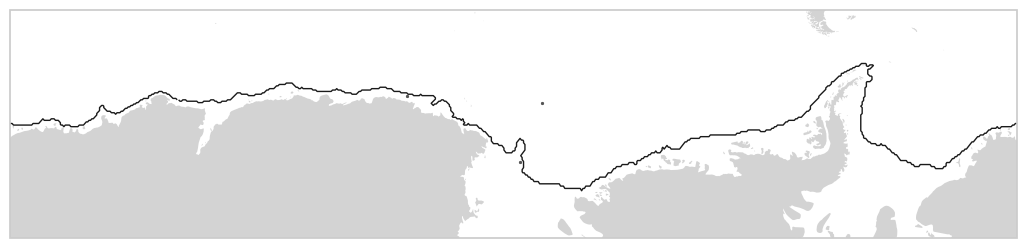

In [12]:
fig = plt.figure(figsize=(13, 5.5))
gs = fig.add_gridspec(1, 2, wspace=0.5)

ax = fig.add_subplot(
    gs[0, :2],
    projection=ccrs.Mercator(
        central_longitude=region["central_longitude"],
        min_latitude=-80,
        max_latitude=-50,
        latitude_true_scale=-70,
    ),
)
add_land(ax)
ax.scatter(
    locs["lon"],
    locs["lat"],
    transform=proj,
    s=2**2,
    facecolors="k",
    edgecolors="k",
    linewidths=0.3,
    alpha=0.75,
)
plot_shelf(ax, c="k")


In [13]:
cm4x_true_column = interpolate_cm4x_to_point(ds, locs).compute()
cm4x_true_column = cm4x_true_column.rename({"depth":"z"})
cm4x_true_column = cm4x_true_column.assign_coords(locs)

cm4x_true_loc = interpolate_depth(cm4x_true_column, locs)
cm4x_true_loc

<xarray.Dataset> Size: 50kB
Dimensions:         (expt: 2, year: 250, obs_loc: 3)
Coordinates:
  * expt            (expt) object 16B 'control' 'forced'
  * year            (year) int64 2kB 1850 1851 1852 1853 ... 2096 2097 2098 2099
  * obs_loc         (obs_loc) <U8 96B 'adelie' 'ross' 'interior'
    print_name      (obs_loc) <U8 96B 'Adélie' 'Ross' 'Interior'
    lat             (obs_loc) float64 24B -66.0 -74.0 -67.0
    lon             (obs_loc) float64 24B 142.0 182.1 190.0
    depth           (obs_loc) float32 12B 280.4 549.1 3.396e+03
    R_km            (obs_loc) float64 24B 50.0 50.0 100.0
Data variables:
    cfc11           (expt, year, obs_loc) float32 6kB nan nan ... 1.421 0.3501
    cfc12           (expt, year, obs_loc) float32 6kB nan nan ... 1.169 0.1784
    sf6             (expt, year, obs_loc) float32 6kB nan nan ... 10.56 0.1402
    sigma2_offline  (expt, year, obs_loc) float64 12kB 37.03 37.08 ... 36.98
    so              (expt, year, obs_loc) float32 6kB 34.46 34.68 ... 34.1 34.71
    thetao          (expt, year, obs_loc) float32 6kB -1.645 -0.3668 ... 0.6803
    z               (expt, year, obs_loc) float32 6kB 235.4 487.4 ... 3.318e+03

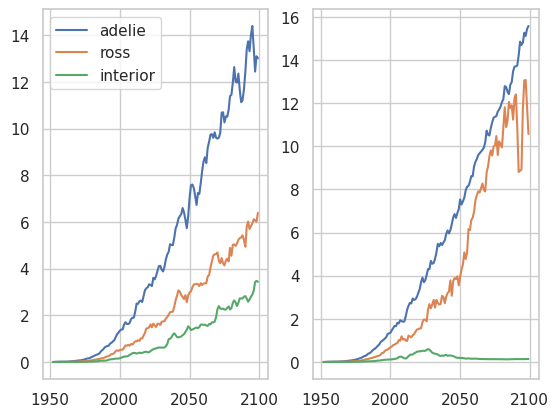

In [14]:
fig,axes = plt.subplots(1, 2)
for source in cm4x_true_loc.obs_loc.values: 
    axes[0].plot(cm4x_true_loc.year, cm4x_true_loc["sf6"].sel(expt = "control", obs_loc = source), label = source)
    axes[1].plot(cm4x_true_loc.year, cm4x_true_loc["sf6"].sel(expt = "forced", obs_loc = source), label = source)

axes[0].legend()

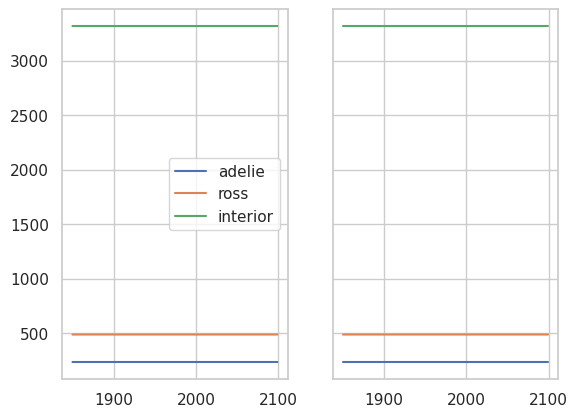

In [15]:
fig,axes = plt.subplots(1, 2, sharey = True)
for source in cm4x_true_loc.obs_loc.values: 
    axes[0].plot(cm4x_true_loc.year, cm4x_true_loc["z"].sel(expt = "control", obs_loc = source), label = source)
    axes[1].plot(cm4x_true_loc.year, cm4x_true_loc["z"].sel(expt = "forced", obs_loc = source), label = source)

axes[0].legend()

In [16]:
lat_cut = -50
near_bottom_cut_meters = 300

cchdo_ds = xr.open_dataset("cchdo_anslope_compiled_data.nc", engine = "h5netcdf")
cchdo_ds = cchdo_ds.where(cchdo_ds.lat <= lat_cut, drop=True)

cchdo_ds["depth"] = np.abs(gsw.z_from_p(cchdo_ds["pressure"], cchdo_ds["lat"]))
cchdo_ds["lon"] = (cchdo_ds["lon"] + 360) % 360

obs = cchdo_ds[["lon", "lat"]]

regridder = xe.Regridder(ds_bottom.deptho, obs, "bilinear", locstream_out=True,     periodic=True,)

cchdo_ds["bottom_dist"] = abs(cchdo_ds.bottom_depth - cchdo_ds.depth)

cchdo_ds = cchdo_ds.assign_coords(near_bottom_cut=near_bottom_cut_meters)

cchdo_ds.near_bottom_cut.attrs = {
    "long_name": "near-bottom cutoff distance",
    "description": (
        "Maximum allowed absolute distance between "
        "sample depth and reported bottom depth for a sample "
        "to be classified as near-bottom."
    ),
    "units": "m",
}

cchdo_ds["near_bottom"] = cchdo_ds.bottom_dist <= cchdo_ds.near_bottom_cut
cchdo_near_bottom = cchdo_ds.where(cchdo_ds.near_bottom, drop=True)

cchdo_near_bottom

<xarray.Dataset> Size: 1MB
Dimensions:             (obs: 8761)
Coordinates:
  * obs                 (obs) int64 70kB 19 20 21 40 ... 449956 449957 450231
    cast                (obs) float64 70kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    lat                 (obs) float64 70kB -64.61 -64.61 ... -66.42 -55.01
    lon                 (obs) float64 70kB 147.6 147.6 147.6 ... 162.7 6.03
    pressure            (obs) float64 70kB 3.501e+03 3.619e+03 ... 3.098e+03
    time                (obs) datetime64[ns] 70kB 2004-10-20T00:53:00 ... 199...
    near_bottom_cut     int64 8B 300
Data variables:
    bottom_depth        (obs) float64 70kB 3.612e+03 3.612e+03 ... 3.063e+03
    cfc11               (obs) float64 70kB 1.711 1.744 1.836 ... 1.364 0.46
    cfc12               (obs) float64 70kB 0.926 0.945 0.992 ... nan nan 0.23
    salinity            (obs) float64 70kB 34.68 34.68 34.68 ... 34.62 34.66
    sf6                 (obs) float64 70kB 0.154 0.157 0.167 ... nan nan nan
    temperature         (obs) float64 70kB -0.1003 -0.1033 ... 0.3146 -0.109
    gebco_bottom_depth  (obs) float32 35kB 3.605e+03 3.605e+03 ... 3.069e+03
    depth               (obs) float64 70kB 3.439e+03 3.553e+03 ... 3.048e+03
    bottom_dist         (obs) float64 70kB 173.5 58.72 58.82 ... 43.28 15.4
    near_bottom         (obs) float64 70kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

In [17]:
def haversine(lon1, lat1, lon2, lat2, R=6371.0):
    # Returns distance in km when R is given in km.
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

In [18]:
mask = {}

for name, p in locs.groupby("obs_loc"):
    m = haversine(ds_bottom.lon, ds_bottom.lat, p.lon, p.lat) < p.R_km

    if name != "interior":
        m &= ASC_contour.astype(bool)

    mask[name] = m *  ds_bottom["wet"].astype(bool)

obs_loc = locs.obs_loc.values

cm4x_true_loc = cm4x_true_loc.assign_coords(
    horiz_proximity_mask=xr.concat(
        [mask[name] for name in obs_loc],
        dim=xr.IndexVariable("obs_loc", obs_loc),
    ).rename({"lon":"model_lon", "lat":"model_lat"})
)

In [19]:
regridder = xe.Regridder(1.0 * cm4x_true_loc["horiz_proximity_mask"].drop_vars(["lon", "lat"]).rename({"model_lon":"lon", "model_lat":"lat"}), 
                         cchdo_near_bottom[["lon", "lat"]], 
                         "nearest_s2d", locstream_out=True, periodic = True)


cm4x_true_loc["real_obs_near_loc"] = regridder(1.0 * cm4x_true_loc["horiz_proximity_mask"]).groupby("time.year").sum("obs")
cm4x_true_loc["real_obs_near_loc"] = cm4x_true_loc["real_obs_near_loc"].where(cm4x_true_loc["real_obs_near_loc"] > 0.0)

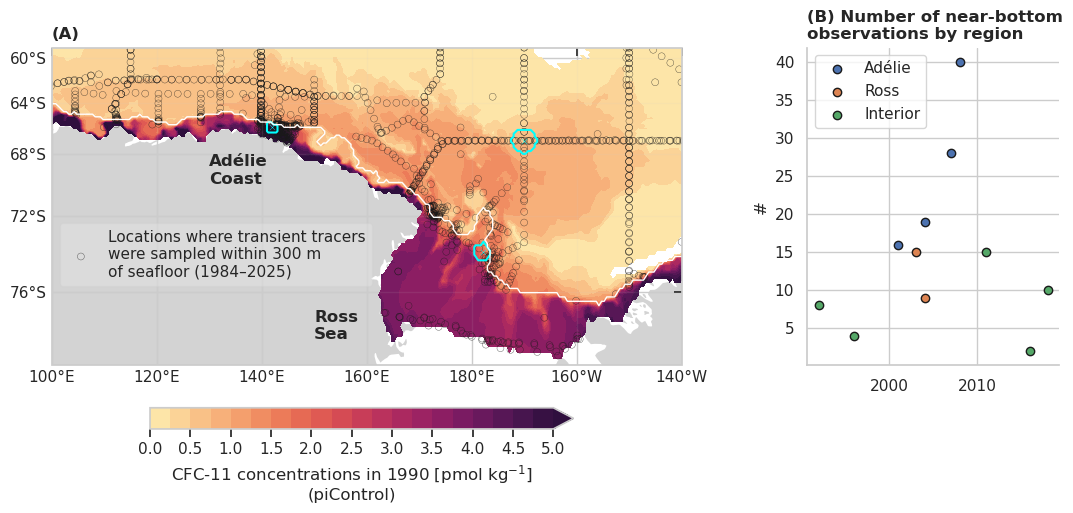

In [20]:
def plot_obs_point(ax, locs, cm4x_true_loc, proj, loc_name, loc_dim="obs_loc", plot_center = False):
    loc = locs.sel({loc_dim: loc_name})
    p = cm4x_true_loc.sel({loc_dim: loc_name})["horiz_proximity_mask"]

    ax.contour(
        p.geolon, p.geolat, p.astype(int),
        levels=[0.5],
        transform=proj,
        colors="cyan",
        linewidths=1.5,
    )
    if plot_center: 
        ax.scatter(loc.lon, loc.lat,
            transform=proj,
            c="cyan",
            s=15,
            marker = "x",
            linewidth=0.3,
            zorder=5,
        )


def plot_obs_points(ax, locs, cm4x_true_loc, proj, loc_dim="obs_loc", plot_center = False):
    for name in locs[loc_dim].values:
        plot_obs_point(
            ax, locs, cm4x_true_loc, proj,
            loc_name=name,
            loc_dim=loc_dim,
            plot_center = plot_center
        )


region = regions["adelie_ross"]
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 5.5))
gs = fig.add_gridspec(1, 3, wspace=0.5)

ax = fig.add_subplot(
    gs[0, :2],
    projection=ccrs.Mercator(
        central_longitude=region["central_longitude"],
        min_latitude=-80,
        max_latitude=-50,
        latitude_true_scale=-70,
    ),
)

ax_occ = fig.add_subplot(gs[0, 2])

ax.set_extent(region["extent"], proj)
add_land(ax)

kw = {"fraction": 0.05, "pad": 0.1}
cb = plot_bottom_cfc(fig, ax, proj, add_colorbar=True, cbar_kwargs=kw)

gl = ax.gridlines(draw_labels=False, crs=proj, alpha=0.1)
gl.xlocator = mticker.FixedLocator(region["xticks"])
gl.ylocator = mticker.FixedLocator(region["yticks"])

ax.set_xticks(region["xticks"], crs=proj)
ax.set_yticks(region["yticks"], crs=proj)
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter())

ax.tick_params(
    direction="in",
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
)

for lon, lat, label in region["labels"]:
    ax.text(lon, lat, label, fontweight="bold", transform=proj)

lon = cchdo_near_bottom["lon"].values
lat = cchdo_near_bottom["lat"].values

pts = np.column_stack([lon, lat])
_, keep = np.unique(pts, axis=0, return_index=True)
keep = np.sort(keep)

lon_u = lon[keep]
lat_u = lat[keep]

ax.scatter(
    lon_u,
    lat_u,
    transform=proj,
    s=5**2,
    facecolors="none",
    edgecolors="k",
    linewidths=0.3,
    label="Locations where transient tracers\nwere sampled within 300 m\nof seafloor (1984–2025)",
    alpha=0.75,
)

plot_obs_points(ax, locs, cm4x_true_loc, proj, loc_dim="obs_loc", plot_center = True)
plot_shelf(ax, c="w")

x, y = ax.projection.transform_point(100, -72, proj)
xa, ya = ax.transAxes.inverted().transform(ax.transData.transform((x, y)))

ax.legend(
    loc="upper left",
    bbox_to_anchor=(xa, ya),
    bbox_transform=ax.transAxes,
    frameon=True,
    framealpha=0.2,
    fontsize=11,
)

ax.set_title("(A)", loc="left", fontweight="bold")

n = cm4x_true_loc["real_obs_near_loc"]
for name in n.obs_loc.values: 
    n_loc = n.sel(obs_loc = name)
    n_loc = n_loc.where(n_loc > 0.0)
    ax_occ.scatter(n.year, n_loc, label = n_loc["print_name"].item(), edgecolor="k", )

# names = locs.print_name
# ax_occ.bar(
#     names,
#     n,
#     color="#0072B2",
#     edgecolor="k",
#     linewidth=0.8,
#     alpha=0.95,
# )

ax_occ.set_title(
    "(B) Number of near-bottom\nobservations by region",
    loc="left",
    fontweight="bold",
)
ax_occ.legend()
ax_occ.set_ylabel("#")
ax_occ.spines[["top", "right"]].set_visible(False)

fig.canvas.draw()

p = ax.get_position()
q = ax_occ.get_position()
ax_occ.set_position([q.x0, p.y0, q.width, p.height])

In [21]:
def variance_explained(x, y, dim="year", threshold = 0.0):
    """
    Variance in `x` explained by `y`: 1 - Var(x - y) / Var(x).

    Not regression R²; `y` is used directly. Negative values mean `y`
    is worse than using the mean of `x`.
    """

    x_filtered = x.where(x > threshold)
    y_filtered = y.where(y > threshold)
    varx = x_filtered.var(dim, skipna=True)
    return (1 - (x_filtered - y_filtered).var(dim, skipna=True) / varx).where(varx > 0)
    
ve = 100 * variance_explained(ds_bottom["cfc11"], cm4x_true_loc["cfc11"], threshold = 0.01).compute()

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


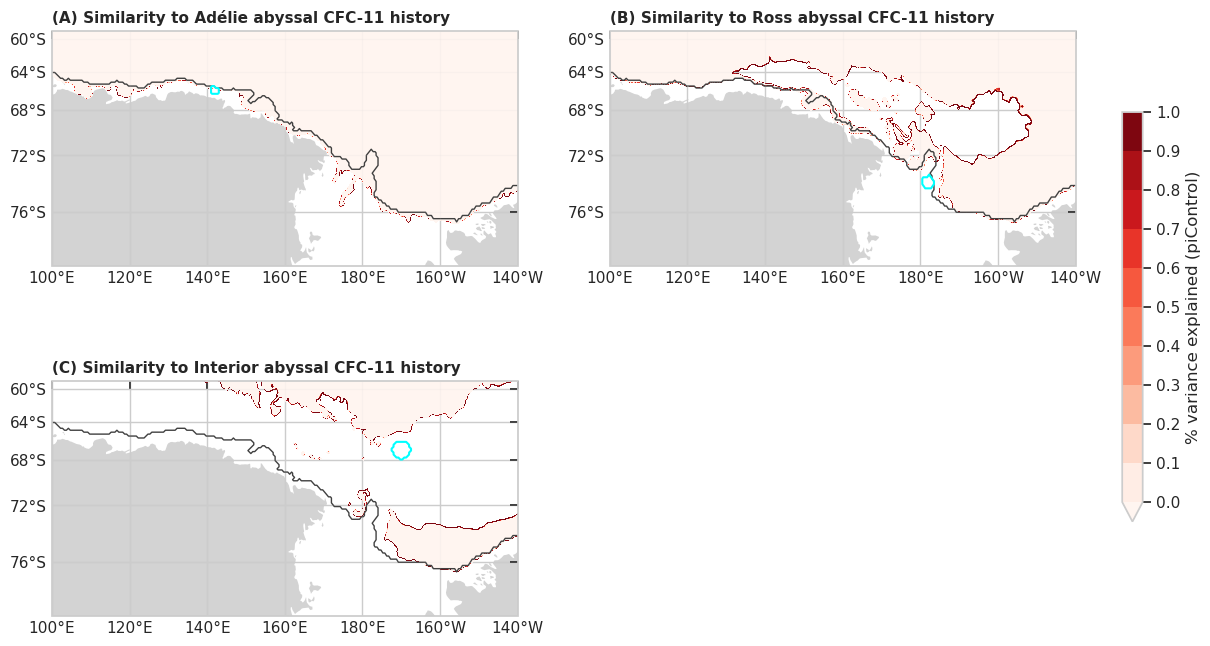

In [22]:
expt = "control"
region = regions["adelie_ross"]
data_proj = ccrs.PlateCarree()

loc_names = cm4x_true_loc.obs_loc.values

letters = ["A", "B", "C", "D"]

levels = np.arange(0, 1.01, 0.1)
ticks = np.arange(0, 1.01, 0.1)

map_proj = ccrs.Mercator(
    central_longitude=region["central_longitude"],
    min_latitude=-80,
    max_latitude=-50,
    latitude_true_scale=-70,
)

fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.02, wspace=0.04)

specs = [gs[0, 0], gs[0, 1], gs[1, 0], gs[1, 1]]
axs = []

for letter, loc_name, spec in zip(letters, loc_names, specs):
    ax = fig.add_subplot(spec, projection=map_proj)
    axs.append(ax)

    da = ve.sel(expt=expt, obs_loc=loc_name)

    cb = ax.contourf(
        da.geolon, da.geolat, da,
        levels=levels,
        transform=data_proj,
        cmap="Reds",
        extend="min",
        transform_first = True,
    )
    ax.set_extent(region["extent"], proj)
    plot_shelf(ax, c="0.25")
    add_land(ax)

    name = locs.sel(obs_loc=loc_name)["print_name"].item()
    plot_obs_point(ax, locs, cm4x_true_loc, proj, loc_name, loc_dim="obs_loc")

    ax.set_title(
        f"({letter}) Similarity to {name} abyssal CFC-11 history",
        loc="left",
        fontweight="bold",
        fontsize=11,
    )
    gl = ax.gridlines(draw_labels=False, crs=proj, alpha=0.1)
    gl.xlocator = mticker.FixedLocator(region["xticks"])
    gl.ylocator = mticker.FixedLocator(region["yticks"])
    
    ax.set_xticks(region["xticks"], crs=proj)
    ax.set_yticks(region["yticks"], crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    
    ax.tick_params(
        direction="in",
        top=True,
        right=True,
        labeltop=False,
        labelright=False,
    )

fig.colorbar(cb, ax=axs,
             ticks=ticks,
             label=f"% variance explained ({expt_names[expt]})",
             fraction=0.02,
             pad=0.02,)

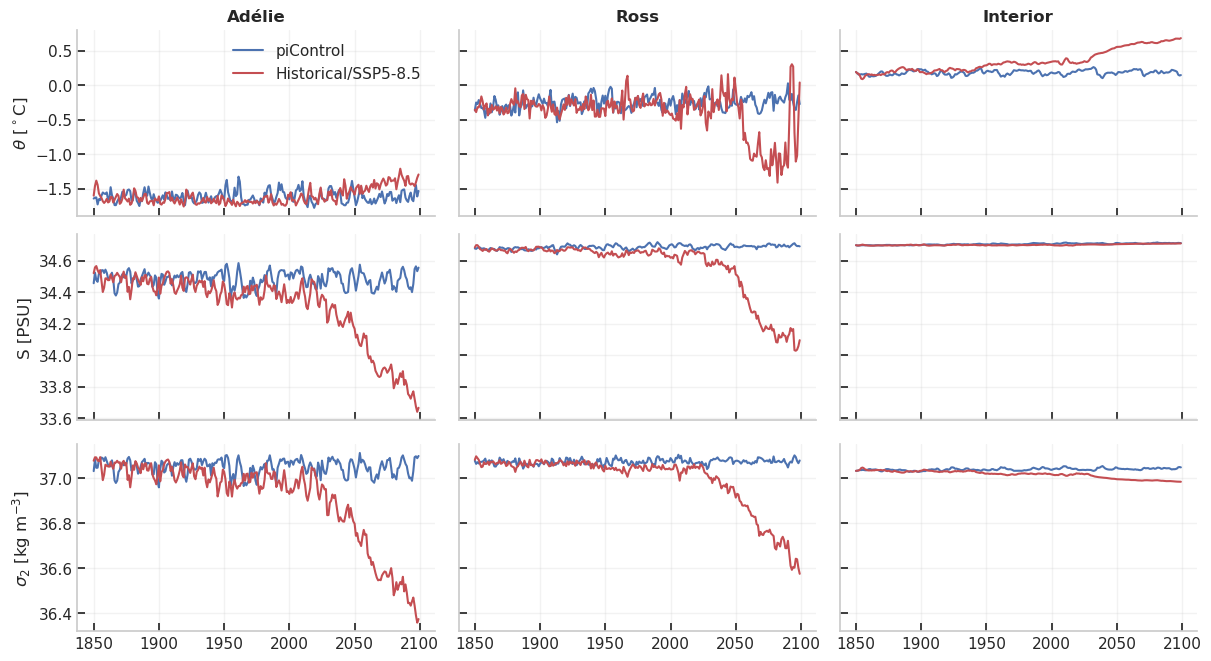

In [23]:
plot_vars = ["thetao", "so", "sigma2_offline"]
var_names = [r"$\theta$ [$^\circ$C]", "S [PSU]", r"$\sigma_2$ [kg m$^{-3}$]"]

true_ds = cm4x_true_loc
loc_vars = true_ds.obs_loc.values

fig, axs = plt.subplots(
    len(plot_vars), len(loc_vars),
    figsize=(12, 6.5),
    sharex=True,
    sharey="row",
    constrained_layout=True,
    gridspec_kw={"wspace": 0.04, "hspace": 0.08},
)

for i, loc in enumerate(loc_vars):
    axs[0, i].set_title(true_ds.sel(obs_loc=loc).print_name.item(), weight="bold")

    for j, var in enumerate(plot_vars):
        axs[j, 0].set_ylabel(var_names[j])

        for expt in true_ds.expt.values:
            axs[j, i].plot(
                true_ds.year,
                true_ds[var].sel(expt=expt, obs_loc=loc),
                c=expt_colors[expt],
                lw=1.5,
                label=expt_names[expt],
            )

for a in axs.flat:
    a.grid(alpha=0.25)
    a.tick_params(direction="in", bottom=True, left=True,
                   top=False, right=False)
    a.spines[["top", "right"]].set_visible(False)

axs[0, 0].legend(frameon=False)

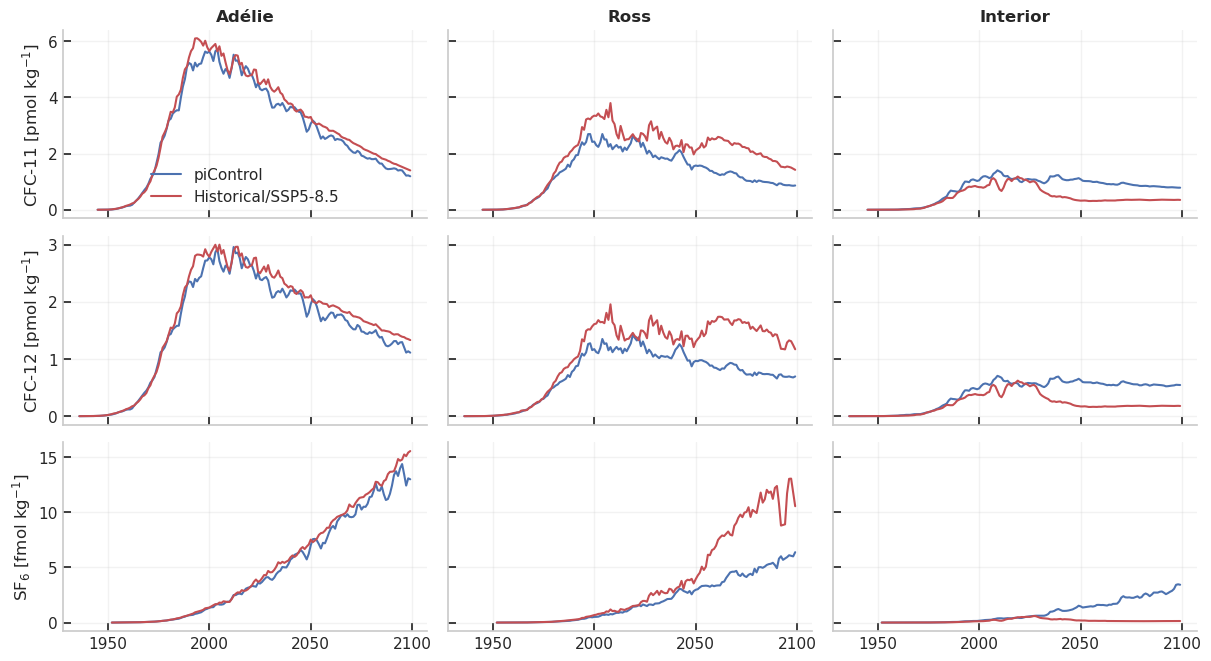

In [24]:
plot_vars = ["cfc11", "cfc12", "sf6"]
var_names = [
    r"CFC-11 [pmol kg$^{-1}$]",
    r"CFC-12 [pmol kg$^{-1}$]",
    r"SF$_6$ [fmol kg$^{-1}$]",
]

true_ds = cm4x_true_column.ffill("z_l").isel(z_l=-1)
loc_vars = true_ds.obs_loc.values
expt_colors = {"forced": "r", "control": "b"}

fig, axs = plt.subplots(
    len(plot_vars), len(loc_vars),
    figsize=(12, 6.5),
    sharex=True,
    sharey="row",
    constrained_layout=True,
    gridspec_kw={"wspace": 0.04, "hspace": 0.08},
)

for i, loc in enumerate(loc_vars):
    axs[0, i].set_title(true_ds.sel(obs_loc=loc).print_name.item(), weight="bold")

    for j, var in enumerate(plot_vars):
        axs[j, 0].set_ylabel(var_names[j])

        for expt in true_ds.expt.values:
            axs[j, i].plot(
                true_ds.year,
                true_ds[var].sel(expt=expt, obs_loc=loc),
                c=expt_colors[expt],
                lw=1.5,
                label=expt_names[expt],
            )

for a in axs.flat:
    a.grid(alpha=0.25)
    a.tick_params(direction="in", bottom=True, left=True, top=False, right=False)
    a.spines[["top", "right"]].set_visible(False)

axs[0, 0].legend(frameon=False, markerscale = 0.7)

In [25]:
tracers = ["cfc11", "cfc12", "sf6", "thetao", "so"]
interior_name = "interior"
source_names = [l for l in cm4x_true_loc["obs_loc"].values if l != interior_name]

src = cm4x_true_loc.sel(obs_loc=source_names)
itr = cm4x_true_loc.sel(obs_loc=interior_name)

ds_b = (
    src[tracers]
    .assign_coords(src.coords)
    .to_array("tracer")
    .rename(obs_loc="source")
)

ds_i = (
    itr[tracers]
    .assign_coords(itr.coords)
    .to_array("tracer")
)



savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"adelie_ross_boundary_sample_for_ttd.zarr"
ds_b.to_zarr(savename, compute = True, mode = "w")

savename = savedir + f"adelie_ross_interior_sample_for_ttd.zarr"
ds_i.to_zarr(savename, compute = True, mode = "w")


/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [26]:
savename = savedir + f"adelie_ross_bottom_samples.zarr"
cm4x_true_loc.to_zarr(savename, compute = True, mode = "w")


In [27]:
savename = savedir + f"adelie_ross_column_samples.zarr"
cm4x_true_column.to_zarr(savename, compute = True, mode = "w")

